# GrabCar Pricing — Chronological CV & Optuna

Notebook ini adalah competition track untuk memaksimalkan skor submission. Raw `type` dan seluruh fitur yang tersedia di train/test boleh dipakai.

Model difokuskan pada Interaction Ridge. `type` asli tetap menjadi fitur wajib; `service_tier_id` menjadi fitur tambahan. Ridge mendapat maksimum 300 trial Optuna dengan feature-group selection dan validasi tiga fold kronologis.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from tqdm.auto import tqdm
from IPython.display import display

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42
N_TRIALS = 300
N_SPLITS = 3
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
print(f'Optuna trials per model: {N_TRIALS}')

Optuna trials per model: 300


## Load data dan bentuk fitur competition track

Raw `type` dipertahankan untuk menangkap baseline 96 kategori. `service_tier_id` dari mapping tiga produk ikut dipakai sebagai sinyal tambahan, bukan pengganti `type`.

In [2]:
train_raw = pd.read_csv(ROOT / 'data/train.csv', parse_dates=['timestamp'])
test_raw = pd.read_csv(ROOT / 'data/test.csv', parse_dates=['timestamp'])
mapping = pd.read_csv(ROOT / 'artifacts/type_cluster_mapping.csv')
assert {'type', 'service_tier_id'}.issubset(mapping.columns)

def make_features(frame):
    out = frame.merge(
        mapping[['type', 'service_tier_id']], on='type', how='left',
        validate='many_to_one'
    )
    assert out['service_tier_id'].notna().all(), 'Ada type yang belum dipetakan.'
    ts = pd.to_datetime(out['timestamp'])
    hour = ts.dt.hour + ts.dt.minute / 60
    dow = ts.dt.dayofweek
    out['distance_km'] = out['distance_mean']
    out['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    out['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    out['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    out['dow_cos'] = np.cos(2 * np.pi * dow / 7)
    out['is_weekend'] = dow.isin([5, 6]).astype('int8')
    return out

train = make_features(train_raw).sort_values('timestamp').reset_index(drop=True)
test = make_features(test_raw).sort_index()
target = 'price_mean'
print('train:', train.shape, '| test:', test.shape)
display(mapping.groupby(['service_tier_id', 'service_tier']).size().rename('n_types'))

train: (20355, 22) | test: (11040, 22)


service_tier_id  service_tier    
1                GrabCar Hemat       25
2                GrabCar Standard    47
3                GrabCar Max         24
Name: n_types, dtype: int64

## Chronological cross-validation

Split dilakukan berdasarkan timestamp unik, bukan posisi baris, sehingga satu timestamp tidak tersebar ke train dan validation sekaligus. Setiap validation fold berada setelah seluruh data training fold-nya.

In [3]:
def chronological_splits(frame, n_splits=3):
    times = np.array(sorted(frame['timestamp'].unique()))
    blocks = np.array_split(times, n_splits + 1)
    splits = []
    for fold in range(n_splits):
        train_times = np.concatenate(blocks[:fold + 1])
        valid_times = blocks[fold + 1]
        train_idx = np.flatnonzero(frame['timestamp'].isin(train_times))
        valid_idx = np.flatnonzero(frame['timestamp'].isin(valid_times))
        splits.append((train_idx, valid_idx))
    return splits

cv_splits = chronological_splits(train, N_SPLITS)
for i, (tr_idx, va_idx) in enumerate(cv_splits, 1):
    print(
        f'Fold {i}: train={len(tr_idx):,} ({train.loc[tr_idx, "timestamp"].min()} → '
        f'{train.loc[tr_idx, "timestamp"].max()}); valid={len(va_idx):,} '
        f'({train.loc[va_idx, "timestamp"].min()} → {train.loc[va_idx, "timestamp"].max()})'
    )

Fold 1: train=5,128 (2018-11-26 06:00:00 → 2018-11-28 16:00:00); valid=5,086 (2018-11-28 17:00:00 → 2018-11-30 21:00:00)
Fold 2: train=10,214 (2018-11-26 06:00:00 → 2018-11-30 21:00:00); valid=5,088 (2018-11-30 22:00:00 → 2018-12-03 02:00:00)
Fold 3: train=15,302 (2018-11-26 06:00:00 → 2018-12-03 02:00:00); valid=5,053 (2018-12-03 03:00:00 → 2018-12-13 23:00:00)


## Optuna objective: feature selection + hyperparameter tuning

`type`, `service_tier_id`, dan `distance_mean` selalu tersedia. Optuna memilih `api_calls`, statistik distance tambahan, surge, cuaca, serta fitur waktu. Interaction Ridge melakukan one-hot encoding pada `type`/tier sebelum menambahkan interaksi orde dua.

In [4]:
WEATHER = ['humidity', 'rain', 'temp', 'wind', 'clouds']
DISTANCE_EXTRA = ['distance_min', 'distance_max']
SURGE = ['surge_min', 'surge_mean', 'surge_max']
HOUR = ['hour_sin', 'hour_cos']
DOW = ['dow_sin', 'dow_cos']

def select_features(trial):
    features = ['type', 'service_tier_id', 'distance_mean']
    if trial.suggest_categorical('use_api_calls', [True, False]):
        features.append('api_calls')
    if trial.suggest_categorical('use_distance_range', [True, False]):
        features += DISTANCE_EXTRA
    if trial.suggest_categorical('use_surge', [True, False]):
        features += SURGE
    for col in WEATHER:
        if trial.suggest_categorical(f'use_{col}', [True, False]):
            features.append(col)
    if trial.suggest_categorical('use_hour', [True, False]):
        features += HOUR
    if trial.suggest_categorical('use_dow', [True, False]):
        features += DOW
    if trial.suggest_categorical('use_weekend', [True, False]):
        features.append('is_weekend')
    return features

def features_from_params(params):
    features = ['type', 'service_tier_id', 'distance_mean']
    if params.get('use_api_calls', False): features.append('api_calls')
    if params.get('use_distance_range', False): features += DISTANCE_EXTRA
    if params.get('use_surge', False): features += SURGE
    features += [c for c in WEATHER if params.get(f'use_{c}', False)]
    if params.get('use_hour', False): features += HOUR
    if params.get('use_dow', False): features += DOW
    if params.get('use_weekend', False): features.append('is_weekend')
    return features

def build_model(model_name, params, features):
    if model_name == 'ridge':
        categorical = [c for c in ['type', 'service_tier_id'] if c in features]
        numeric = [c for c in features if c not in categorical]
        preprocessor = ColumnTransformer([
            ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
            ('numeric', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), numeric),
        ], sparse_threshold=1.0)
        steps = [('preprocessor', preprocessor)]
        if params.get('interactions', True):
            steps.append(('interactions', PolynomialFeatures(
                degree=2, interaction_only=True, include_bias=False)))
        estimator = Ridge(alpha=params['alpha'])
        steps.append(('model', estimator))
        return Pipeline(steps)
    raise ValueError(model_name)

def suggest_model_params(trial, model_name):
    if model_name == 'ridge':
        return {'alpha': trial.suggest_float('alpha', 1e-3, 1e4, log=True),
                'interactions': trial.suggest_categorical('interactions', [True, False])}
    raise ValueError(model_name)

def objective_factory(model_name):
    def objective(trial):
        features = select_features(trial)
        model_params = suggest_model_params(trial, model_name)
        fold_rmse = []
        fold_mae = []
        for fold, (tr_idx, va_idx) in enumerate(cv_splits):
            model = build_model(model_name, model_params, features)
            model.fit(train.loc[tr_idx, features], train.loc[tr_idx, target])
            pred = model.predict(train.loc[va_idx, features])
            fold_rmse.append(mean_squared_error(train.loc[va_idx, target], pred) ** .5)
            fold_mae.append(mean_absolute_error(train.loc[va_idx, target], pred))
            trial.report(np.mean(fold_rmse), fold)
            if trial.should_prune():
                raise optuna.TrialPruned()
        trial.set_user_attr('features', features)
        trial.set_user_attr('mean_mae', float(np.mean(fold_mae)))
        return float(np.mean(fold_rmse))
    return objective

class TqdmCallback:
    def __init__(self, total, label):
        self.bar = tqdm(total=total, desc=label, unit='trial')
    def __call__(self, study, trial):
        self.bar.update(1)
        self.bar.set_postfix(best_rmse=f'{study.best_value:.5f}')
    def close(self):
        self.bar.close()

## Jalankan tuning

Trace trial tampil melalui progress bar tqdm. Study disimpan ke SQLite agar tuning dapat dilanjutkan jika kernel berhenti.

In [5]:
MODEL_NAMES = ['ridge']
studies = {}
for model_name in MODEL_NAMES:
    storage = f'sqlite:///{ROOT / "experiments/grabcar_optuna.db"}'
    study = optuna.create_study(
        study_name=f'grabcar_linear_stack_v4_{model_name}', direction='minimize', storage=storage,
        load_if_exists=True, sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1)
    )
    remaining = max(0, N_TRIALS - len(study.trials))
    if remaining:
        callback = TqdmCallback(remaining, f'Optuna {model_name}')
        study.optimize(objective_factory(model_name), n_trials=remaining, callbacks=[callback])
        callback.close()
    studies[model_name] = study
    print(f'{model_name}: best RMSE={study.best_value:.6f}, trials={len(study.trials)}')

leaderboard = pd.DataFrame([
    {
        'model': name, 'cv_rmse': study.best_value,
        'cv_mae': study.best_trial.user_attrs.get('mean_mae'),
        'features': ', '.join(study.best_trial.user_attrs.get('features', [])),
    }
    for name, study in studies.items()
]).sort_values('cv_rmse')
display(leaderboard)

Optuna ridge:   0%|          | 0/260 [00:00<?, ?trial/s]

ridge: best RMSE=0.558075, trials=300


,model,cv_rmse,cv_mae,features
0,ridge,0.558075,0.40655,"type, service_tier_id, distance_mean, surge_mi..."


## Train full data dan hasilkan seluruh submission

Setiap model terbaik dilatih ulang pada seluruh train. Weighted blend memakai bobot inverse-CV-RMSE.

In [6]:
submission_template = pd.read_csv(ROOT / 'data/sample_submission.csv')
predictions = {}
best_config = {}

for model_name, study in studies.items():
    params = study.best_params.copy()
    features = features_from_params(params)
    model = build_model(model_name, params, features)
    model.fit(train[features], train[target])
    pred = model.predict(test[features])
    predictions[model_name] = pred

    submission = submission_template.copy()
    submission['price_mean'] = pred
    output_path = ROOT / 'outputs/submissions' / f'submission_grabcar_{model_name}.csv'
    submission.to_csv(output_path, index=False)
    best_config[model_name] = {
        'cv_rmse': study.best_value, 'features': features, 'params': params
    }
    print(f'Saved {output_path}')

weights = np.array([1 / studies[name].best_value for name in MODEL_NAMES])
weights /= weights.sum()
blend_pred = sum(w * predictions[name] for w, name in zip(weights, MODEL_NAMES))
blend = submission_template.copy()
blend['price_mean'] = blend_pred
blend.to_csv(ROOT / 'outputs/submissions/submission_grabcar_weighted_blend.csv', index=False)

with open(ROOT / 'experiments/grabcar_best_configs.json', 'w') as f:
    json.dump(best_config, f, indent=2, default=float)
print('Saved submission_grabcar_weighted_blend.csv and grabcar_best_configs.json')

Saved submission_grabcar_ridge.csv
Saved submission_grabcar_weighted_blend.csv and grabcar_best_configs.json


## Chronological OOF stacking

Setiap base model menghasilkan prediksi OOF walk-forward. Meta-Ridge hanya belajar dari prediksi yang dibuat oleh model yang tidak pernah melihat target pada validation fold tersebut.

In [7]:
oof_matrix = np.full((len(train), len(MODEL_NAMES)), np.nan)
base_oof_scores = {}

for model_idx, model_name in enumerate(MODEL_NAMES):
    study = studies[model_name]
    params = study.best_params.copy()
    features = features_from_params(params)
    for tr_idx, va_idx in cv_splits:
        fold_model = build_model(model_name, params, features)
        fold_model.fit(train.loc[tr_idx, features], train.loc[tr_idx, target])
        oof_matrix[va_idx, model_idx] = fold_model.predict(train.loc[va_idx, features])
    mask = np.isfinite(oof_matrix[:, model_idx])
    base_oof_scores[model_name] = mean_squared_error(
        train.loc[mask, target], oof_matrix[mask, model_idx]
    ) ** .5

oof_mask = np.isfinite(oof_matrix).all(axis=1)
X_meta = oof_matrix[oof_mask]
y_meta = train.loc[oof_mask, target].to_numpy()
meta_times = train.loc[oof_mask, 'timestamp'].reset_index(drop=True)

# Evaluasi meta-model dengan chronological split kedua agar skor stack tidak in-sample.
meta_frame = pd.DataFrame({'timestamp': meta_times})
meta_splits = chronological_splits(meta_frame, n_splits=3)
meta_oof = np.full(len(X_meta), np.nan)
for tr_idx, va_idx in meta_splits:
    meta_fold = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=np.logspace(-6, 3, 100)))
    ])
    meta_fold.fit(X_meta[tr_idx], y_meta[tr_idx])
    meta_oof[va_idx] = meta_fold.predict(X_meta[va_idx])
meta_mask = np.isfinite(meta_oof)
stack_cv_rmse = mean_squared_error(y_meta[meta_mask], meta_oof[meta_mask]) ** .5

meta_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-6, 3, 100)))
])
meta_model.fit(X_meta, y_meta)
X_test_meta = np.column_stack([predictions[name] for name in MODEL_NAMES])
stack_test_pred = meta_model.predict(X_test_meta)

stack_submission = submission_template.copy()
stack_submission['price_mean'] = stack_test_pred
stack_submission.to_csv(ROOT / 'outputs/submissions/submission_chronological_stack.csv', index=False)
print('Base OOF RMSE:', base_oof_scores)
print(f'Nested chronological stack RMSE: {stack_cv_rmse:.6f}')
print('Meta coefficients:', dict(zip(MODEL_NAMES, meta_model.named_steps['ridge'].coef_)))
print('Saved submission_chronological_stack.csv')

Base OOF RMSE: {'ridge': 0.5580883192351641}
Nested chronological stack RMSE: 0.557832
Meta coefficients: {'ridge': 8.913468683013583}
Saved submission_chronological_stack.csv


## Verifikasi output dan plot trace Optuna

submission_grabcar_ridge.csv {'min': 4.042882981165148, 'mean': 19.386756102317715, 'max': 46.10568206277874}
submission_grabcar_weighted_blend.csv {'min': 4.042882981165148, 'mean': 19.386756102317715, 'max': 46.10568206277874}
submission_chronological_stack.csv {'min': 4.065001493409335, 'mean': 19.389281510197304, 'max': 46.07408918118085}


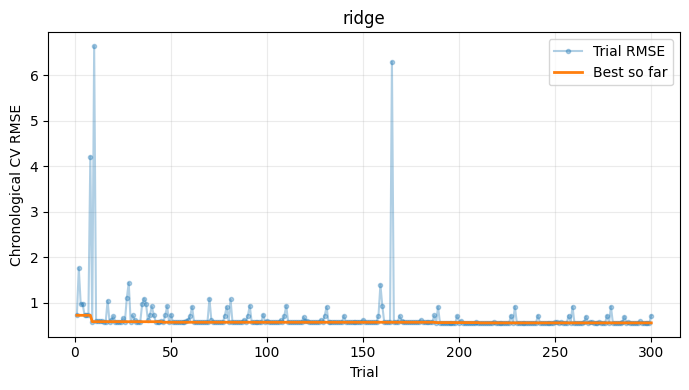

In [8]:
submission_files = [ROOT / 'outputs/submissions' / f'submission_grabcar_{name}.csv' for name in MODEL_NAMES]
submission_files.append(ROOT / 'outputs/submissions/submission_grabcar_weighted_blend.csv')
submission_files.append(ROOT / 'outputs/submissions/submission_chronological_stack.csv')
for path in submission_files:
    sub = pd.read_csv(path)
    assert list(sub.columns) == list(submission_template.columns)
    assert len(sub) == len(submission_template)
    assert np.isfinite(sub['price_mean']).all()
    print(path.name, sub['price_mean'].describe()[['min', 'mean', 'max']].to_dict())

fig, axes = plt.subplots(1, len(studies), figsize=(7, 4), sharey=True)
for ax, (name, study) in zip(np.atleast_1d(axes), studies.items()):
    completed = [t for t in study.trials if t.value is not None]
    values = np.array([t.value for t in completed])
    best_so_far = np.minimum.accumulate(values)
    ax.plot(range(1, len(values) + 1), values, alpha=.35, marker='.', label='Trial RMSE')
    ax.plot(range(1, len(values) + 1), best_so_far, linewidth=2, label='Best so far')
    ax.set(title=name, xlabel='Trial', ylabel='Chronological CV RMSE')
    ax.grid(alpha=.25)
    ax.legend()
plt.tight_layout()
plt.show()